In [1]:
import pandas as pd

data=pd.read_csv("./语料库/data_10w.csv")
data.head

<bound method NDFrame.head of                                                         0  \
0                                  ㈦ 制定 商品 融资 和 风险管理 办法 ；   
1                         D . 安全 理事会 与 国际 刑事警察 组织 之间 的 合作   
2       109 . 造成 本项 下 差异 的 主要 因素 是 2007 / 08 年度 和 2008...   
3       纪念 世界 土壤 日 ( 12 月 5 日 ) 和 启动 国际 土壤 年 特别 活动 ( 大...   
4       匈牙利 对 《 语言 法 》 的 限制性 规定 表示 关切 ， 敦促 斯洛伐克 通过 更加 ...   
...                                                   ...   
499995  13 . 将 继续 根据 联合国 国家 工作队 的 需求 ， 由 指导 委员会 和 协调 小...   
499996                              A / 58 / PV . 56 和 92   
499997  资金 转移 可以 是 现金 方式 ， 也 可 通过 贸易 公司 或 空壳 公司 在 地方 、...   
499998  三是 加大 依法 支付 农民工 工资 的 宣传 力度 ， 大力 推动 用人单位 全面落实 "...   
499999  还 回顾 《 联合国 打击 跨国 有 组织 犯罪 公约 》 及 《 联合国 打击 跨国 有 ...   

                                                        1  
0       ( VII ) Develop commodity financing and risk m...  
1       D. Cooperation between the Security Council an...  
2       109 . the main factor contributing to the vari...

In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from sklearn.model_selection import train_test_split

# 固定随机种子，保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

2025-12-01 07:56:56.381465: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-01 07:56:56.381584: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-01 07:56:56.418396: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# -------------------------- 1. 加载与清洗数据 --------------------------
# 加载10万条语料（建议先采样1万条练手，全量训练较慢）
df = pd.read_csv("./语料库/data_10w.csv", header=None)  # 若csv无表头，header=None
# 假设第0列是中文（源语言），第1列是英文（目标语言），需根据实际列名调整！
df.columns = ["chinese", "english"]
df = df.sample(n=100000, random_state=42)  # 采样，全量训练可删除此句

# 文本清洗函数
def clean_chinese(text):
    """清洗中文：保留分词后的空格，仅过滤非中文/空格的字符"""
    text = re.sub(r"[^\u4e00-\u9fa5\s]", "", str(text))  # 只保留中文字符和空格
    return text.strip()  # 去除首尾空格（中间的空格是分词分隔符，保留）

def clean_english(text):
    """优化：保留字母、空格、连字符(-)、撇号(')（合法英文符号）"""
    text = str(text).lower()
    # 只过滤非字母、非空格、非-、非'的字符
    text = re.sub(r"[^a-zA-Z\s'-]", "", text)
    # 合并连续空格
    text = re.sub(r"\s+", " ", text).strip()
    # 添加<start>/<end>
    return f"<start> {text} <end>" if text else "<start> <end>"

# 执行清洗
df["chinese_clean"] = df["chinese"].apply(clean_chinese)
df["english_clean"] = df["english"].apply(clean_english)

# 过滤空句子
df = df[df["chinese_clean"] != ""].reset_index(drop=True)
df = df[df["english_clean"] != "<start>  <end>"].reset_index(drop=True)

# 在数据清洗后、构建词表前执行
print("=== 数据有效性检查 ===")
print(f"中文空句子数量：{df['chinese_clean'].eq('').sum()}")
print(f"英文空句子数量：{df['english_clean'].eq('<start>  <end>').sum()}")
# 提前定义正则表达式（r前缀保留，反斜杠合法）
pattern = r'[^\u4e00-\u9fa5\s]'
# f-string 中引用变量，而非直接写正则
print(f"中文含非中文字符/空格的句子数量：{df['chinese_clean'].str.contains(pattern, na=False).sum()}")

print(f"\n过滤后剩余有效数据行数：{len(df)}")

# 构建词表前添加词频统计，动态设置min_freq
def get_optimal_min_freq(texts, is_chinese=True):
    all_tokens = [token.strip() for text in texts for token in text.split() if token.strip() != ""]
    token_freq = Counter(all_tokens)
    # 目标：词表大小控制在 5000-20000（中文）、10000-30000（英文）
    if is_chinese:
        target_vocab_size = 10000
    else:
        target_vocab_size = 20000
    
    # 从小到大调整min_freq，找到接近目标词表大小的阈值
    for min_freq in range(1, 10):
        filtered = [token for token, freq in token_freq.items() if freq >= min_freq]
        if len(filtered) <= target_vocab_size:
            return min_freq
    return 2  # 默认值

# -------------------------- 2. 构建词表 --------------------------
def build_vocab(texts, min_freq=2, is_chinese=True):
    """重构词表函数：强制固定特殊token位置，确保有效词正确加入"""
    # 1. 拆分token
    all_tokens = [token.strip() for text in texts for token in text.split() if token.strip() != ""]
    
    # 2. 统计词频，过滤低频词（保留特殊token除外）
    token_freq = Counter(all_tokens)
    # 英文需保留<start>和<end>（但清洗后文本已包含，此处确保不被过滤）
    if not is_chinese:
        filtered_tokens = [token for token, freq in token_freq.items() if freq >= min_freq or token in ["<start>", "<end>"]]
    else:
        filtered_tokens = [token for token, freq in token_freq.items() if freq >= min_freq]
    
    # 3. 构建词表：强制固定特殊token的ID，避免混乱
    word2id = {}
    # 第一步：添加通用特殊token（<pad>、<unk>）
    word2id["<pad>"] = 0
    word2id["<unk>"] = 1
    # 第二步：英文添加<start>、<end>（固定ID=2、3）
    if not is_chinese:
        word2id["<start>"] = 2
        word2id["<end>"] = 3
    # 第三步：添加过滤后的有效词（从当前词表长度开始分配ID）
    for token in filtered_tokens:
        if token not in word2id:  # 避免重复添加
            word2id[token] = len(word2id)
    
    # 4. 反向构建id2word
    id2word = {idx: token for token, idx in word2id.items()}
    vocab_size = len(word2id)
    
    # 打印关键信息（验证是否正确）
    print(f"=== 词表构建结果 ===")
    print(f"词表大小：{vocab_size}")
    print(f"特殊token ID：")
    for token in ["<pad>", "<unk>", "<start>", "<end>"]:
        if token in word2id:
            print(f"  {token}: {word2id[token]}")
    # 验证目标token（albanian）是否在词表中
    if not is_chinese and "albanian" in word2id:
        print(f"\n✅ 'albanian' 已加入词表，ID：{word2id['albanian']}")
    elif not is_chinese:
        print(f"\n❌ 'albanian' 未加入词表，词频：{token_freq.get('albanian', 0)}")
    
    return word2id, id2word, vocab_size

# 构建词表时使用动态min_freq
zh_min_freq = get_optimal_min_freq(df["chinese_clean"], is_chinese=True)
en_min_freq = get_optimal_min_freq(df["english_clean"], is_chinese=False)

zh_word2id, zh_id2word, zh_vocab_size = build_vocab(df["chinese_clean"], min_freq=zh_min_freq, is_chinese=True)
en_word2id, en_id2word, en_vocab_size = build_vocab(df["english_clean"], min_freq=en_min_freq, is_chinese=False)

# -------------------------- 3. 序列编码与Padding（统一句子长度） --------------------------
def text_to_seq(texts, word2id, max_len, is_chinese=True):
    seqs = []
    vocab_size = len(word2id)
    unk_id = word2id["<unk>"]
    pad_id = word2id["<pad>"]
    
    for text in texts:
        # 拆分token+强制去空格（解决隐形空格问题）
        tokens = [token.strip() for token in text.split() if token.strip() != ""]
        seq = []
        for token in tokens:
            # 关键：强制查找词表，找不到直接设为<unk>
            if token in word2id:
                token_id = word2id[token]
            else:
                token_id = unk_id
            # 双重保险：确保ID不超出词表范围
            if token_id >= vocab_size:
                token_id = unk_id
            seq.append(token_id)
        
        # Padding/截断
        if len(seq) < max_len:
            seq += [pad_id] * (max_len - len(seq))
        else:
            seq = seq[:max_len]
        seqs.append(seq)
    
    return np.array(seqs)

# 统计句子长度，设置最大长度（避免Padding过多）
zh_max_len = max([len(text.split()) for text in df["chinese_clean"]])
en_max_len = max([len(text.split()) for text in df["english_clean"]])
print(f"中文最大词数：{zh_max_len}，英文最大单词数：{en_max_len}")

# 编码为ID序列
X = text_to_seq(df["chinese_clean"], zh_word2id, zh_max_len, is_chinese=True)  # 中文输入（源序列）
y = text_to_seq(df["english_clean"], en_word2id, en_max_len, is_chinese=False)  # 英文输出（目标序列）

# 划分训练集/验证集（9:1）
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

=== 数据有效性检查 ===
中文空句子数量：0
英文空句子数量：0
中文含非中文字符/空格的句子数量：0

过滤后剩余有效数据行数：98141
=== 词表构建结果 ===
词表大小：9676
特殊token ID：
  <pad>: 0
  <unk>: 1
=== 词表构建结果 ===
词表大小：19255
特殊token ID：
  <pad>: 0
  <unk>: 1
  <start>: 2
  <end>: 3

✅ 'albanian' 已加入词表，ID：10752
中文最大词数：73，英文最大单词数：79


In [4]:
def write_tfrecord_fixed_len(X, y, output_path, zh_max_len, en_max_len, zh_word2id, en_word2id):
    """
    修正：兼容 numpy 数组，先转列表再拼接
    :param X: 中文ID序列（numpy数组，已Padding到zh_max_len）
    :param y: 英文ID序列（numpy数组，已Padding到en_max_len）
    """
    zh_pad_id = zh_word2id["<pad>"]
    en_pad_id = en_word2id["<pad>"]
    
    writer = tf.io.TFRecordWriter(output_path)
    for x_seq, y_seq in zip(X, y):
        # 关键：将numpy数组转为Python列表（避免广播错误）
        x_seq = x_seq.tolist()
        y_seq = y_seq.tolist()
        
        # 双重保障：确保序列是固定长度（截断/补0）
        if len(x_seq) < zh_max_len:
            x_seq += [zh_pad_id] * (zh_max_len - len(x_seq))
        if len(y_seq) < en_max_len:
            y_seq += [en_pad_id] * (en_max_len - len(y_seq))
        
        # 定义固定长度特征（int64_list，长度=max_len）
        feature = {
            "chinese_seq": tf.train.Feature(
                int64_list=tf.train.Int64List(value=x_seq)
            ),
            "english_seq": tf.train.Feature(
                int64_list=tf.train.Int64List(value=y_seq)
            )
        }
        # 构建Example
        example = tf.train.Example(features=tf.train.Features(feature=feature))
        writer.write(example.SerializeToString())
    writer.close()
    print(f"✅ TFRecord已保存到：{output_path}")

# 执行写入（参数不变，直接用）
write_tfrecord_fixed_len(X_train, y_train, "./train.tfrecord", zh_max_len, en_max_len, zh_word2id, en_word2id)
write_tfrecord_fixed_len(X_val, y_val, "./val.tfrecord", zh_max_len, en_max_len, zh_word2id, en_word2id)


def parse_tfrecord_fixed_len(example_proto):
    """
    解析固定长度的TFRecord（仅接收1个参数，与map传参逻辑一致）
    """
    # 特征描述：必须和写入时的格式完全一致（固定长度）
    feature_description = {
        "chinese_seq": tf.io.FixedLenFeature([zh_max_len], tf.int64),  # 长度=zh_max_len
        "english_seq": tf.io.FixedLenFeature([en_max_len], tf.int64)   # 长度=en_max_len
    }
    # 解析单个Example（返回字典）
    parsed_example = tf.io.parse_single_example(example_proto, feature_description)
    
    # 转换为int32（TensorFlow模型默认接收int32输入）
    chinese_seq = tf.cast(parsed_example["chinese_seq"], tf.int32)
    english_seq = tf.cast(parsed_example["english_seq"], tf.int32)
    
    return chinese_seq, english_seq  # 返回（输入序列，目标序列），符合模型训练格式

# 构建Dataset
batch_size = 64
buffer_size = 10000

# 训练集
train_dataset = tf.data.TFRecordDataset(
    "./train.tfrecord",
    num_parallel_reads=4  # 并行读取（提升速度）
)
# map解析：仅传入函数名，不额外传参（函数自动接收1个example_proto参数）
train_dataset = train_dataset.map(
    parse_tfrecord_fixed_len,
    num_parallel_calls=tf.data.AUTOTUNE  # 并行解析
)
train_dataset = train_dataset.shuffle(buffer_size=buffer_size)
train_dataset = train_dataset.batch(batch_size, drop_remainder=True)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)  # 预取数据

# 验证集（逻辑和训练集一致）
val_dataset = tf.data.TFRecordDataset("./val.tfrecord", num_parallel_reads=4)
val_dataset = val_dataset.map(parse_tfrecord_fixed_len, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size, drop_remainder=True)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

✅ TFRecord已保存到：./train.tfrecord
✅ TFRecord已保存到：./val.tfrecord


In [5]:
# 验证TFRecord文件是否生成，且能正常解析
test_dataset = tf.data.TFRecordDataset("./train.tfrecord").map(parse_tfrecord_fixed_len)
for chinese_seq, english_seq in test_dataset.take(1):
    print(f"中文序列shape：{chinese_seq.shape}")  # (zh_max_len,)
    print(f"英文序列shape：{english_seq.shape}")  # (en_max_len,)
    print("✅ TFRecord写入+解析正常")

中文序列shape：(73,)
英文序列shape：(79,)
✅ TFRecord写入+解析正常


In [6]:
# 1. 验证词表中的albanian
print(f"albanian 是否在词表中：{'albanian' in en_word2id}")
if "albanian" in en_word2id:
    print(f"albanian 的ID：{en_word2id['albanian']}")
else:
    print(f"albanian 词频：{Counter([token for text in df['english_clean'] for token in text.split()])['albanian']}")

# 2. 验证编码后的ID
print(f"\n英文词表大小：{en_vocab_size}")
print(f"英文ID最大值：{y.max()}")
print(f"所有ID是否在词表范围内：{np.all(y < en_vocab_size)}")  # 必须输出True
print(f"溢出ID数量：{len(y[y >= en_vocab_size])}")  # 必须输出0

albanian 是否在词表中：True
albanian 的ID：10752

英文词表大小：19255
英文ID最大值：19254
所有ID是否在词表范围内：True
溢出ID数量：0


In [7]:
# 1. 先查看英文词表中的特殊token是否存在（关键！）
print("=== 英文词表特殊token检查 ===")
special_tokens = ["<pad>", "<unk>", "<start>", "<end>"]
for token in special_tokens:
    if token in en_word2id:
        print(f"{token}: ID={en_word2id[token]}")
    else:
        print(f"❌ 词表中缺少特殊token：{token}")

# 2. 找到编码后超出词表的ID对应的原始token
print("\n=== 定位溢出ID的来源 ===")
# 取英文序列中所有超出词表的ID
overflow_ids = y[y >= en_vocab_size]
if len(overflow_ids) > 0:
    print(f"超出词表的ID：{np.unique(overflow_ids)}")
    
    # 找到这些ID对应的原始token（以第一条溢出数据为例）
    overflow_idx = np.where(y >= en_vocab_size)[0][0]  # 第一个溢出数据的索引
    overflow_seq = y[overflow_idx]  # 该数据的英文ID序列
    overflow_token_pos = np.where(overflow_seq >= en_vocab_size)[0]  # 溢出ID的位置
    
    # 找到原始文本
    original_english = df["english_clean"].iloc[overflow_idx]
    tokens = original_english.split()  # 按空格拆词
    print(f"原始英文文本：{original_english}")
    print(f"拆分后的token：{tokens}")
    print(f"溢出ID的位置：{overflow_token_pos}")
    print(f"对应token：{[tokens[pos] for pos in overflow_token_pos]}")
else:
    print("✅ 无超出词表的ID")

=== 英文词表特殊token检查 ===
<pad>: ID=0
<unk>: ID=1
<start>: ID=2
<end>: ID=3

=== 定位溢出ID的来源 ===
✅ 无超出词表的ID


In [8]:
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        # 定义公式中的可训练参数
        self.W_h = tf.keras.layers.Dense(units)  # 对编码器隐藏状态h_i的线性变换
        self.W_s = tf.keras.layers.Dense(units)  # 对解码器隐藏状态s_{t-1}的线性变换
        self.v = tf.keras.layers.Dense(1)        # 对tanh结果的线性变换（输出维度1）

    def call(self, encoder_outputs, decoder_hidden):
        """
        输入：
            encoder_outputs：编码器所有时间步输出，shape=(batch_size, zh_max_len, units)
            decoder_hidden：解码器前一步隐藏状态，shape=(batch_size, units)
        输出：
            context_vector：上下文向量（加权求和），shape=(batch_size, units)
            attention_weights：注意力权重，shape=(batch_size, zh_max_len, 1)
        """
        # 扩展decoder_hidden维度，适配编码器输出的时间步（zh_max_len）
        decoder_hidden_with_time = tf.expand_dims(decoder_hidden, axis=1)  # (batch, 1, units)
        
        # 计算注意力分数：score = v^T · tanh(W_h·h_i + W_s·s_{t-1})
        score = self.v(tf.nn.tanh(
            self.W_h(encoder_outputs) + self.W_s(decoder_hidden_with_time)
        ))  # (batch_size, zh_max_len, 1)
        
        # 归一化分数得到注意力权重（softmax）
        attention_weights = tf.nn.softmax(score, axis=1)  # (batch_size, zh_max_len, 1)
        
        # 加权求和得到上下文向量（注意力权重 × 编码器输出）
        context_vector = attention_weights * encoder_outputs  # (batch, zh_max_len, units)
        context_vector = tf.reduce_sum(context_vector, axis=1)  # (batch, units)
        
        return context_vector, attention_weights

In [9]:
class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units, batch_size):
        super(Encoder, self).__init__()
        self.batch_size = batch_size
        self.enc_units = enc_units  # LSTM单元数
        # 嵌入层：将中文ID转为稠密向量
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim, mask_zero=True)
        # LSTM层：输出所有时间步的隐藏状态（给注意力用）和最终隐藏状态（初始化解码器）
        self.lstm = tf.keras.layers.LSTM(
            self.enc_units,
            return_sequences=True,  # 输出所有时间步结果
            return_state=True,      # 输出最终隐藏状态和细胞状态
            recurrent_initializer="glorot_uniform"
        )

    def call(self, x, hidden):
        """
        输入：x（中文ID序列，shape=(batch, zh_max_len)）、hidden（初始隐藏状态）
        输出：enc_outputs（所有时间步输出）、state_h（最终隐藏状态）、state_c（最终细胞状态）
        """
        x = self.embedding(x)  # (batch, zh_max_len, embedding_dim)
        enc_outputs, state_h, state_c = self.lstm(x, initial_state=hidden)
        return enc_outputs, state_h, state_c

    def initialize_hidden_state(self):
        """初始化LSTM的隐藏状态和细胞状态（全零）"""
        return (tf.zeros((self.batch_size, self.enc_units)),
                tf.zeros((self.batch_size, self.enc_units)))

In [10]:
class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units, batch_size):
        super(Decoder, self).__init__()
        self.batch_size = batch_size
        self.dec_units = dec_units
        # 嵌入层：将英文ID转为稠密向量
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim, mask_zero=True)
        # LSTM层：处理目标序列
        self.lstm = tf.keras.layers.LSTM(
            self.dec_units,
            return_sequences=True,
            return_state=True,
            recurrent_initializer="glorot_uniform"
        )
        # 全连接层：输出预测的英文单词概率（词表大小）
        self.fc = tf.keras.layers.Dense(vocab_size)
        # 集成Bahdanau注意力层
        self.attention = BahdanauAttention(self.dec_units)

    def call(self, x, hidden, enc_outputs):
        """
        输入：x（英文ID序列，训练时用教师强制，shape=(batch, 1)）、hidden（解码器初始隐藏状态）、enc_outputs（编码器输出）
        输出：predictions（预测概率）、state_h（解码器新隐藏状态）、state_c（解码器新细胞状态）、attention_weights（注意力权重）
        """
        # 1. 注意力计算：得到上下文向量和权重
        context_vector, attention_weights = self.attention(enc_outputs, hidden[0])
        
        # 2. 嵌入层：x是单个时间步的输入（教师强制时每次喂1个单词）
        x = self.embedding(x)  # (batch, 1, embedding_dim)
        
        # 3. 拼接上下文向量与嵌入向量（融合编码器信息和解码器当前输入）
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)  # (batch, 1, embedding_dim + dec_units)
        
        # 4. LSTM前向传播
        output, state_h, state_c = self.lstm(x)  # (batch, 1, dec_units)
        
        # 5. 全连接层预测
        predictions = self.fc(tf.reshape(output, (-1, output.shape[2])))  # (batch*1, en_vocab_size)
        
        return predictions, state_h, state_c, attention_weights

I0000 00:00:1764547069.262689     646 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1/20 | 训练损失：1.8396 | 验证损失：1.7005
Epoch 2/20 | 训练损失：1.6471 | 验证损失：1.5929
Epoch 3/20 | 训练损失：1.5524 | 验证损失：1.5128
Epoch 4/20 | 训练损失：1.4720 | 验证损失：1.4514
Epoch 5/20 | 训练损失：1.4025 | 验证损失：1.3914
Epoch 6/20 | 训练损失：1.3380 | 验证损失：1.3417
Epoch 7/20 | 训练损失：1.2808 | 验证损失：1.2986
Epoch 8/20 | 训练损失：1.2294 | 验证损失：1.2614
Epoch 9/20 | 训练损失：1.1824 | 验证损失：1.2301
Epoch 10/20 | 训练损失：1.1394 | 验证损失：1.2029
Epoch 11/20 | 训练损失：1.1001 | 验证损失：1.1789
Epoch 12/20 | 训练损失：1.0639 | 验证损失：1.1583
Epoch 13/20 | 训练损失：1.0308 | 验证损失：1.1413
Epoch 14/20 | 训练损失：1.0001 | 验证损失：1.1294
Epoch 15/20 | 训练损失：0.9718 | 验证损失：1.1173
Epoch 16/20 | 训练损失：0.9454 | 验证损失：1.1077
Epoch 17/20 | 训练损失：0.9212 | 验证损失：1.1013
Epoch 18/20 | 训练损失：0.8987 | 验证损失：1.0914
Epoch 19/20 | 训练损失：0.8770 | 验证损失：1.0862
Epoch 20/20 | 训练损失：0.8570 | 验证损失：1.0843


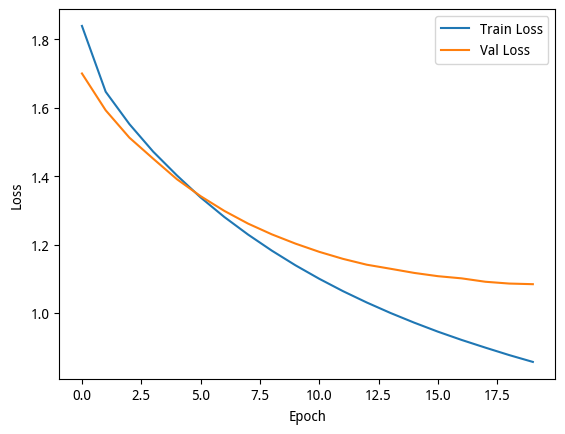

In [11]:
# -------------------------- 1. 超参数设置 --------------------------
embedding_dim = 256  # 嵌入向量维度
enc_units = 256      # 编码器LSTM单元数
dec_units = 256      # 解码器LSTM单元数（与编码器一致，简化注意力计算）
epochs = 20          # 训练轮次（根据验证集loss调整，避免过拟合）

# 初始化编码器、解码器
encoder = Encoder(zh_vocab_size, embedding_dim, enc_units, batch_size)
decoder = Decoder(en_vocab_size, embedding_dim, dec_units, batch_size)

# 损失函数（稀疏交叉熵：无需对目标序列做One-Hot，直接用ID）
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction=tf.keras.losses.Reduction.NONE
)

# 优化器
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)

# 记录损失（用于后续绘图）
train_losses = []
val_losses = []

# -------------------------- 2. 定义损失计算函数（过滤Padding的损失） --------------------------
def compute_loss(real, pred):
    loss_ = loss_object(real, pred)
    mask = tf.math.logical_not(tf.math.equal(real, 0))  # 0是<pad>，mask为False
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask  # 屏蔽Padding的损失
    return tf.reduce_mean(loss_)


# -------------------------- 3. 训练循环（@tf.function加速计算） --------------------------
@tf.function
def train_step(inp, targ, enc_hidden):
    loss = 0
    with tf.GradientTape() as tape:
        # 原有逻辑不变（编码器+解码器前向传播）
        enc_outputs, enc_h, enc_c = encoder(inp, enc_hidden)
        dec_hidden = (enc_h, enc_c)
        dec_input = tf.expand_dims([en_word2id["<start>"]] * batch_size, 1)
        
        for t in range(1, targ.shape[1]):
            predictions, dec_h, dec_c, _ = decoder(dec_input, dec_hidden, enc_outputs)
            loss += compute_loss(targ[:, t], predictions)
            dec_input = tf.expand_dims(targ[:, t], 1)
            dec_hidden = (dec_h, dec_c)
    
    batch_loss = (loss / int(targ.shape[1]))
    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)
    
    # 新增：梯度裁剪（范数最大设为5.0，可调整）
    gradients, _ = tf.clip_by_global_norm(gradients, 5.0)
    
    optimizer.apply_gradients(zip(gradients, variables))
    return batch_loss


# -------------------------- 4. 执行训练与验证 --------------------------
# -------------------------- 4. 执行训练与验证 --------------------------
for epoch in range(epochs):
    # ================================== 训练阶段（解决TypeError）==================================
    enc_hidden = encoder.initialize_hidden_state()
    total_train_loss = 0
    train_batch_count = 0  # 训练批次计数器（替代len(train_dataset)）

    for (batch, (inp, targ)) in enumerate(train_dataset):
        # 计算单批次训练损失
        batch_loss = train_step(inp, targ, enc_hidden)
        total_train_loss += batch_loss  # 累加总损失
        train_batch_count += 1  # 批次计数+1

    # 计算平均训练损失（用计数器替代len(train_dataset)）
    avg_train_loss = total_train_loss / train_batch_count  # 关键修正：无len()调用
    train_losses.append(avg_train_loss.numpy())

    # ================================== 验证阶段（解决NameError）==================================
    total_val_loss = 0
    val_batch_count = 0  # 验证批次计数器

    for (batch, (inp, targ)) in enumerate(val_dataset):
        # 1. 编码器前向传播（原有逻辑，补充完整）
        enc_hidden_val = encoder.initialize_hidden_state()
        enc_outputs_val, enc_h_val, enc_c_val = encoder(inp, enc_hidden_val)
        dec_hidden_val = (enc_h_val, enc_c_val)
        dec_input_val = tf.expand_dims([en_word2id["<start>"]] * batch_size, 1)
        
        # 2. 初始化单批次验证损失（必须先定义，避免NameError）
        batch_val_loss = 0  # 关键修正：提前声明批次损失变量

        # 3. 解码器循环计算损失（原有逻辑，补充损失累加）
        for t in range(1, targ.shape[1]):
            predictions_val, dec_h_val, dec_c_val, _ = decoder(
                dec_input_val, dec_hidden_val, enc_outputs_val
            )
            # 累加单时间步损失
            batch_val_loss += compute_loss(targ[:, t], predictions_val)
            # 更新解码器输入和隐藏状态
            dec_input_val = tf.expand_dims(targ[:, t], 1)
            dec_hidden_val = (dec_h_val, dec_c_val)
        
        # 4. 计算单批次平均损失（按序列长度归一化）
        batch_val_loss = batch_val_loss / int(targ.shape[1])  # 关键修正：计算批次平均损失
        # 5. 累加总验证损失+计数批次
        total_val_loss += batch_val_loss
        val_batch_count += 1

    # 计算平均验证损失（用计数器替代len(val_dataset)）
    avg_val_loss = total_val_loss / val_batch_count
    val_losses.append(avg_val_loss.numpy())

    # 打印每轮日志
    print(f"Epoch {epoch+1}/{epochs} | 训练损失：{avg_train_loss:.4f} | 验证损失：{avg_val_loss:.4f}")

# 后续模型保存、损失曲线绘制逻辑保持不变
encoder.save_weights("./encoder_weights.h5")
decoder.save_weights("./decoder_weights.h5")

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [12]:
def translate_and_visualize(chinese_text, encoder, decoder, max_length_en):
    """
    输入：中文句子、编码器、解码器、英文最大长度
    输出：生成的英文句子、注意力权重热力图
    """
    # -------------------------- 1. 预处理输入中文 --------------------------
    # 清洗+转ID序列
    chinese_clean = clean_chinese(chinese_text)
    zh_tokens = [char for char in chinese_clean if char != " "]
    zh_seq = [zh_word2id.get(token, zh_word2id["<unk>"]) for token in zh_tokens]
    # Padding到zh_max_len
    if len(zh_seq) < zh_max_len:
        zh_seq += [zh_word2id["<pad>"]] * (zh_max_len - len(zh_seq))
    else:
        zh_seq = zh_seq[:zh_max_len]
    zh_seq = tf.expand_dims(zh_seq, 0)  # 加batch维度：(1, zh_max_len)
    
    # -------------------------- 2. 编码器前向传播 --------------------------
    enc_hidden = (tf.zeros((1, enc_units)), tf.zeros((1, enc_units)))  # batch=1
    enc_outputs, enc_h, enc_c = encoder(zh_seq, enc_hidden)
    dec_hidden = (enc_h, enc_c)
    
    # -------------------------- 3. 解码器自回归生成英文 --------------------------
    dec_input = tf.expand_dims([en_word2id["<start>"]], 0)  # 初始输入：<start>
    result = []  # 存储生成的英文单词
    attention_weights_list = []  # 存储每个时间步的注意力权重
    
    for t in range(max_length_en):
        predictions, dec_h, dec_c, attention_weights = decoder(dec_input, dec_hidden, enc_outputs)
        # 记录注意力权重（去掉batch维度）
        attention_weights_list.append(tf.squeeze(attention_weights).numpy())
        # 取概率最大的token ID
        predicted_id = tf.argmax(predictions[0]).numpy()
        # 转成单词，若遇到<end>则停止
        if en_id2word[predicted_id] == "<end>":
            break
        result.append(en_id2word[predicted_id])
        # 下一步输入：当前预测的token ID
        dec_input = tf.expand_dims([predicted_id], 0)
        dec_hidden = (dec_h, dec_c)
    
    # 生成最终英文句子
    generated_english = " ".join(result)
    
    # -------------------------- 4. 注意力权重可视化（热力图） --------------------------
    # 处理注意力权重：取有效长度（去掉Padding的中文token）
    valid_zh_tokens = [token for token in zh_tokens if token != zh_word2id["<pad>"]]
    attention_weights = np.array(attention_weights_list)[:len(result)]  # 只取生成单词对应的权重
    
    # 绘制热力图
    plt.figure(figsize=(12, 8))
    ax = plt.subplot(111)
    im = ax.imshow(attention_weights, cmap="YlOrRd")  # 热力图颜色映射
    
    # 设置坐标轴标签
    ax.set_xticks(range(len(valid_zh_tokens)))
    ax.set_xticklabels(valid_zh_tokens, rotation=45)
    ax.set_yticks(range(len(result)))
    ax.set_yticklabels(result)
    
    # 添加颜色条
    cbar = plt.colorbar(im)
    cbar.set_label("Attention Weight", rotation=270, labelpad=20)
    
    # 每个格子添加权重数值（可选）
    for i in range(len(result)):
        for j in range(len(valid_zh_tokens)):
            text = ax.text(j, i, f"{attention_weights[i, j]:.2f}",
                          ha="center", va="center", color="black" if attention_weights[i, j] < 0.5 else "white")
    
    plt.title(f"Chinese: {chinese_text}\nGenerated English: {generated_english}")
    plt.tight_layout()
    plt.show()
    
    return generated_english

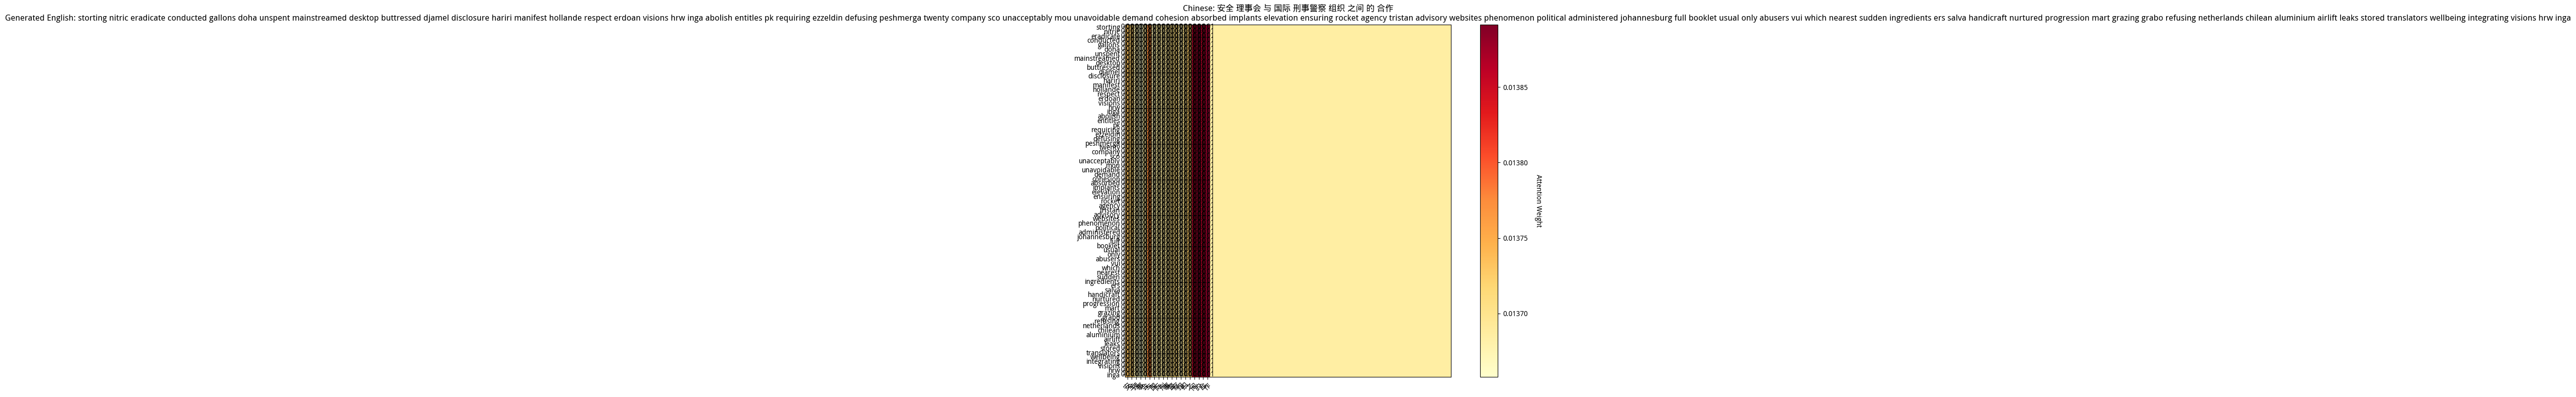

中文输入：安全 理事会 与 国际 刑事警察 组织 之间 的 合作
英文生成：storting nitric eradicate conducted gallons doha unspent mainstreamed desktop buttressed djamel disclosure hariri manifest hollande respect erdoan visions hrw inga abolish entitles pk requiring ezzeldin defusing peshmerga twenty company sco unacceptably mou unavoidable demand cohesion absorbed implants elevation ensuring rocket agency tristan advisory websites phenomenon political administered johannesburg full booklet usual only abusers vui which nearest sudden ingredients ers salva handicraft nurtured progression mart grazing grabo refusing netherlands chilean aluminium airlift leaks stored translators wellbeing integrating visions hrw inga


In [24]:
test_chinese = "安全 理事会 与 国际 刑事警察 组织 之间 的 合作"
generated_english = translate_and_visualize(test_chinese, encoder, decoder, en_max_len)
print(f"中文输入：{test_chinese}")
print(f"英文生成：{generated_english}")